# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [2]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [9]:
# ── Load cleaned data ─────────────────────────────────────────────────────────
df = pd.read_csv('aviation_cleaned.csv', low_memory=False)

print("\n── Shape ──")
print(df.shape)
print("\n── Preview ──")
display(df.head())



── Shape ──
(17958, 32)

── Preview ──


,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Report.Status,Publication.Date,Total.Passengers,Injury.Fraction,is_destroyed,Make_Model
0,20001214X42478,Incident,LAX83IA149A,1983-03-18,"LOS ANGELES, CA",United States,NaN,NaN,LAX,LOS ANGELES INTL,...,0.0,0.0,588.0,VMC,Probable Cause,04-12-2014,588.0,0.0,0.0,Boeing 747
1,20001214X42331,Accident,ATL83FA140,1983-03-20,"CROSSVILLE, TN",United States,NaN,NaN,NaN,NaN,...,1.0,0.0,0.0,IMC,Probable Cause,02-05-2011,2.0,1.0,1.0,Piper PA-28-140
2,20001214X42672,Accident,FTW83LA177,1983-04-02,"MCKINNEY, TX",United States,NaN,NaN,TX05,AERO COUNTRY,...,0.0,0.0,4.0,VMC,Probable Cause,17-10-2016,5.0,0.2,NaN,De Havilland DHC-6
3,20001214X45013,Incident,CHI84IA041,1983-11-08,"CHICAGO, IL",United States,NaN,NaN,ORD,O'HARE,...,0.0,0.0,100.0,VMC,Probable Cause,11-06-2018,100.0,0.0,0.0,Boeing 727-200
4,20001214X45188,Accident,NYC84LA028,1983-11-13,"MARTHA'S VINEYARD, MA",United States,NaN,NaN,NaN,NaN,...,0.0,0.0,1.0,VMC,Probable Cause,05-05-2011,1.0,0.0,0.0,Beechcraft C35


## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [10]:
# ── Inspect Total.Passengers distribution ────────────────────────────────────
print("── Total.Passengers summary ──")
print(df['Total.Passengers'].describe())

print(f"\nRows with 0 or NaN passengers: {(df['Total.Passengers'] <= 0).sum()}")

── Total.Passengers summary ──
count    17958.000000
mean         9.502283
std         38.272771
min          0.000000
25%          1.000000
50%          2.000000
75%          2.000000
max        588.000000
Name: Total.Passengers, dtype: float64

Rows with 0 or NaN passengers: 791


In [12]:
# ── Split into small and large aircraft ───────────────────────────────────────

# Threshold: 20 passengers
# < 20  → small aircraft  (general aviation, private, commuter)
# >= 20 → large aircraft  (commercial, regional jets, airliners)
# This gives two distinct groups matching the client's request for
# separate recommendations.

THRESHOLD = 20

df_small = df[df['Total.Passengers'] < THRESHOLD].copy()
df_large = df[df['Total.Passengers'] >= THRESHOLD].copy()

print(f"── Small aircraft (< {THRESHOLD} passengers): {df_small.shape[0]:,} records ──")
print(f"── Large aircraft (>= {THRESHOLD} passengers): {df_large.shape[0]:,} records ──")


── Small aircraft (< 20 passengers): 17,043 records ──
── Large aircraft (>= 20 passengers): 915 records ──


In [13]:
# ── Preview key metrics in each group ────────────────────────────────────────
for label, subset in [('Small', df_small), ('Large', df_large)]:
    print(f"\n── {label} Aircraft ──")
    print(subset[['Injury.Fraction', 'is_destroyed']].describe().round(3))


── Small Aircraft ──
       Injury.Fraction  is_destroyed
count        16252.000     16370.000
mean             0.287         0.109
std              0.432         0.311
min              0.000         0.000
25%              0.000         0.000
50%              0.000         0.000
75%              0.800         0.000
max              1.000         1.000

── Large Aircraft ──
       Injury.Fraction  is_destroyed
count          915.000       495.000
mean             0.061         0.107
std              0.221         0.310
min              0.000         0.000
25%              0.000         0.000
50%              0.000         0.000
75%              0.000         0.000
max              1.000         1.000


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

In [14]:
# ── 1. Calculating Mean injury ───────────────────

def top15_safest_makes(df_group, label):
    """
    Returns the 15 Makes with the lowest mean Injury.Fraction,
    excluding Makes with fewer than 50 records for statistical robustness.
    """
    make_stats = (df_group.groupby('Make')['Injury.Fraction']
                           .agg(['mean', 'count'])
                           .rename(columns={'mean': 'Mean.Injury.Fraction', 
                                            'count': 'Count'})
                           .query('Count >= 50')
                           .sort_values('Mean.Injury.Fraction')
                           .head(15))
    
    print(f"\n── Top 15 Safest Makes: {label} Aircraft ──")
    print(make_stats.round(4))
    return make_stats

top15_small = top15_safest_makes(df_small, 'Small')
top15_large = top15_safest_makes(df_large, 'Large')


── Top 15 Safest Makes: Small Aircraft ──
                                Mean.Injury.Fraction  Count
Make                                                       
Boeing                                        0.1420    272
Aviat Aircraft Inc                            0.1645     76
Maule                                         0.1648    215
Grumman Acft Eng Cor-Schweizer                0.2069     58
Ayres                                         0.2157     51
Stinson                                       0.2164    129
Aviat                                         0.2214     70
Bellanca                                      0.2226    219
Diamond Aircraft Ind Inc                      0.2230     74
Rockwell International                        0.2237     57
Aeronca                                       0.2258    200
Champion                                      0.2605    158
Cessna                                        0.2638   7058
American Champion Aircraft                    0.2692     

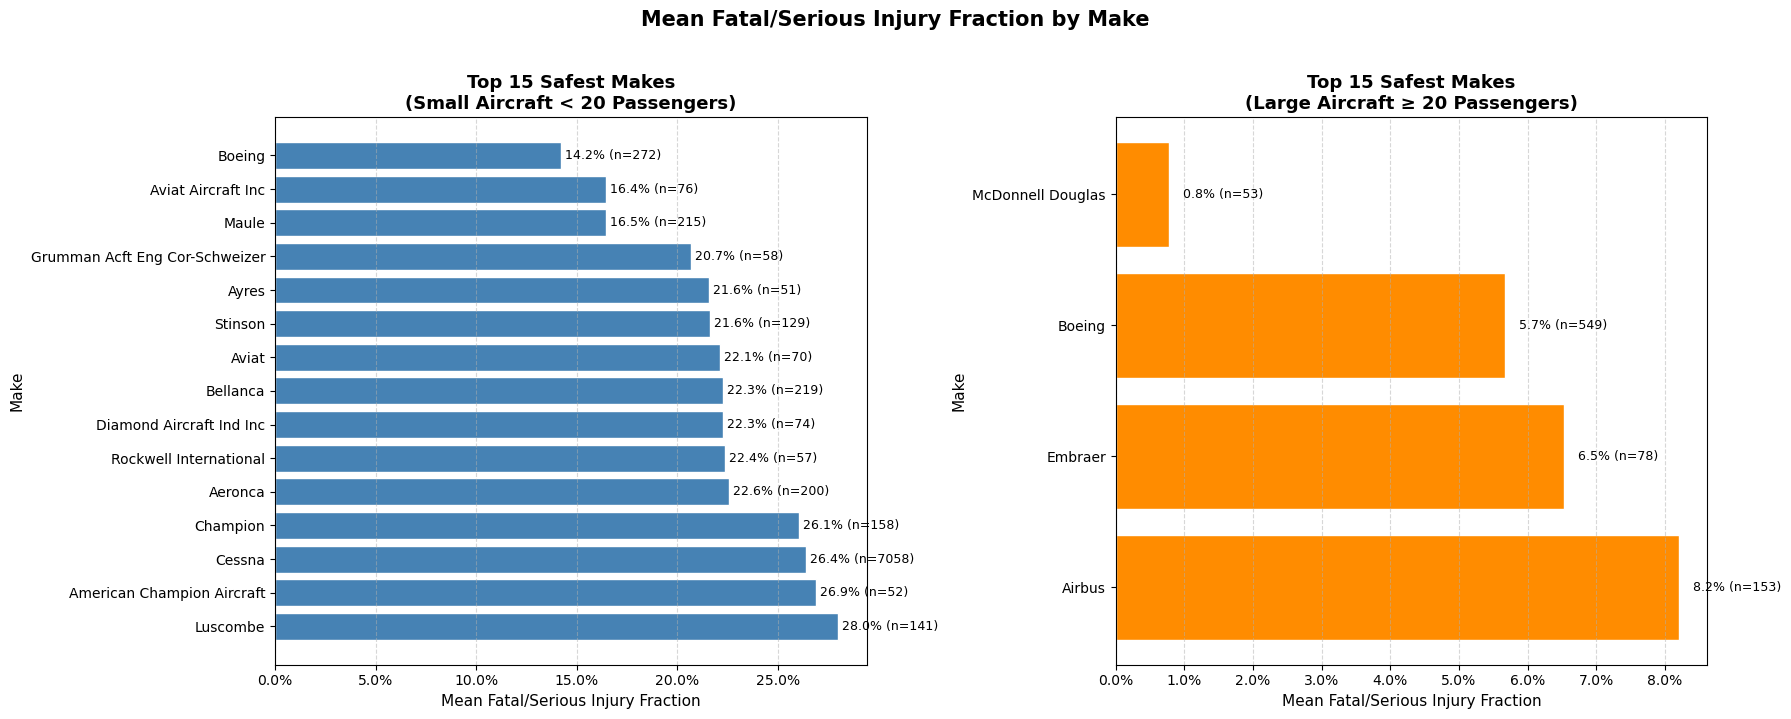

In [15]:
# ── 2. Plot side-by-side ──────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Small aircraft ──
axes[0].barh(top15_small.index, 
             top15_small['Mean.Injury.Fraction'],
             color='steelblue', edgecolor='white')
axes[0].set_title('Top 15 Safest Makes\n(Small Aircraft < 20 Passengers)', 
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Mean Fatal/Serious Injury Fraction', fontsize=11)
axes[0].set_ylabel('Make', fontsize=11)
axes[0].invert_yaxis()  # safest make at top
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))
axes[0].grid(axis='x', linestyle='--', alpha=0.5)

# Annotate bars
for i, (val, count) in enumerate(zip(top15_small['Mean.Injury.Fraction'], 
                                      top15_small['Count'])):
    axes[0].text(val + 0.002, i, f'{val:.1%} (n={count})', 
                 va='center', fontsize=9)

# ── Large aircraft ──
axes[1].barh(top15_large.index, 
             top15_large['Mean.Injury.Fraction'],
             color='darkorange', edgecolor='white')
axes[1].set_title('Top 15 Safest Makes\n(Large Aircraft ≥ 20 Passengers)', 
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Mean Fatal/Serious Injury Fraction', fontsize=11)
axes[1].set_ylabel('Make', fontsize=11)
axes[1].invert_yaxis()
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))
axes[1].grid(axis='x', linestyle='--', alpha=0.5)

# Annotate bars
for i, (val, count) in enumerate(zip(top15_large['Mean.Injury.Fraction'], 
                                      top15_large['Count'])):
    axes[1].text(val + 0.002, i, f'{val:.1%} (n={count})', 
                 va='center', fontsize=9)

plt.suptitle('Mean Fatal/Serious Injury Fraction by Make', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

In [18]:
# ── 1. Get top 10 safest Makes for small aircraft ─────────────────────────────

top10_small_makes = (df_small.groupby('Make')['Injury.Fraction']
                              .agg(['mean', 'count'])
                              .rename(columns={'mean': 'Mean.Injury.Fraction',
                                               'count': 'Count'})
                              .query('Count >= 50')
                              .sort_values('Mean.Injury.Fraction')
                              .head(10))

print("── Top 10 Safest Makes (Small Aircraft) ──")
print(top10_small_makes.round(4))

# Filter df_small to only these makes
top10_small_names = top10_small_makes.index.tolist()
df_small_top10 = df_small[df_small['Make'].isin(top10_small_names)].copy()

── Top 10 Safest Makes (Small Aircraft) ──
                                Mean.Injury.Fraction  Count
Make                                                       
Boeing                                        0.1420    272
Aviat Aircraft Inc                            0.1645     76
Maule                                         0.1648    215
Grumman Acft Eng Cor-Schweizer                0.2069     58
Ayres                                         0.2157     51
Stinson                                       0.2164    129
Aviat                                         0.2214     70
Bellanca                                      0.2226    219
Diamond Aircraft Ind Inc                      0.2230     74
Rockwell International                        0.2237     57


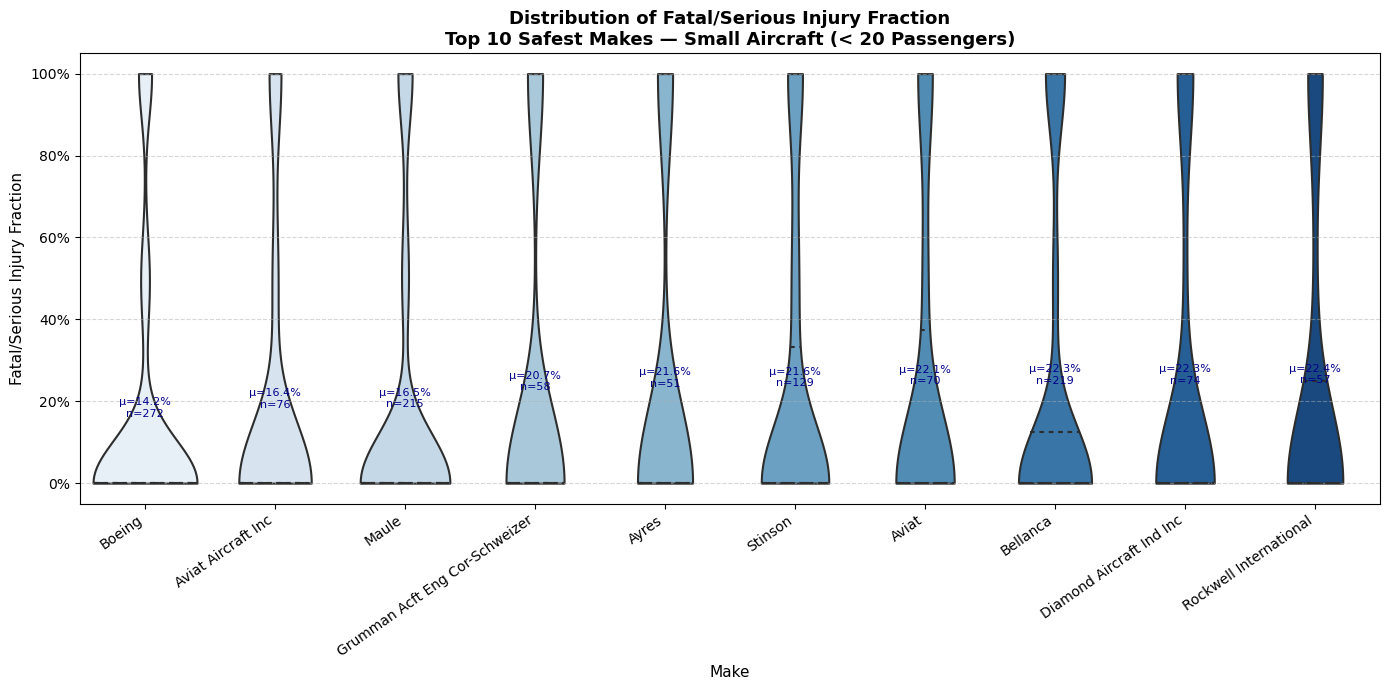

In [19]:
# ── 2. Violin plot ────────────────────────────────────────────────────────────

order = top10_small_makes.index.tolist()

fig, ax = plt.subplots(figsize=(14, 7))

sns.violinplot(
    data=df_small_top10,
    x='Make',
    y='Injury.Fraction',
    order=order,
    palette='Blues',
    inner='quartile',   # shows median and IQR lines inside violin
    cut=0,              # restrict violin to observed data range
    ax=ax
)

# Formatting
ax.set_title('Distribution of Fatal/Serious Injury Fraction\nTop 10 Safest Makes — Small Aircraft (< 20 Passengers)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Make', fontsize=11)
ax.set_ylabel('Fatal/Serious Injury Fraction', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Annotate mean per make
for i, make in enumerate(order):
    mean_val = top10_small_makes.loc[make, 'Mean.Injury.Fraction']
    count    = top10_small_makes.loc[make, 'Count']
    ax.text(i, mean_val + 0.02, f'μ={mean_val:.1%}\nn={count}',
            ha='center', fontsize=8, color='darkblue')

plt.tight_layout()
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

In [20]:
# ── 1. Get top 10 safest Makes for large aircraft ─────────────────────────────

top10_large_makes = (df_large.groupby('Make')['Injury.Fraction']
                              .agg(['mean', 'count'])
                              .rename(columns={'mean': 'Mean.Injury.Fraction',
                                               'count': 'Count'})
                              .query('Count >= 50')
                              .sort_values('Mean.Injury.Fraction')
                              .head(10))

print("── Top 10 Safest Makes (Large Aircraft) ──")
print(top10_large_makes.round(4))

# Filter df_large to only these makes
top10_large_names = top10_large_makes.index.tolist()
df_large_top10 = df_large[df_large['Make'].isin(top10_large_names)].copy()

── Top 10 Safest Makes (Large Aircraft) ──
                   Mean.Injury.Fraction  Count
Make                                          
McDonnell Douglas                0.0078     53
Boeing                           0.0568    549
Embraer                          0.0653     78
Airbus                           0.0820    153


C:\Users\Eng.Joe\AppData\Local\Temp\ipykernel_13236\3808108785.py:7: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(
c:\Users\Eng.Joe\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Eng.Joe\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Eng.Joe\AppData\Local\Temp\ipykernel_13236\3808108785.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=10)


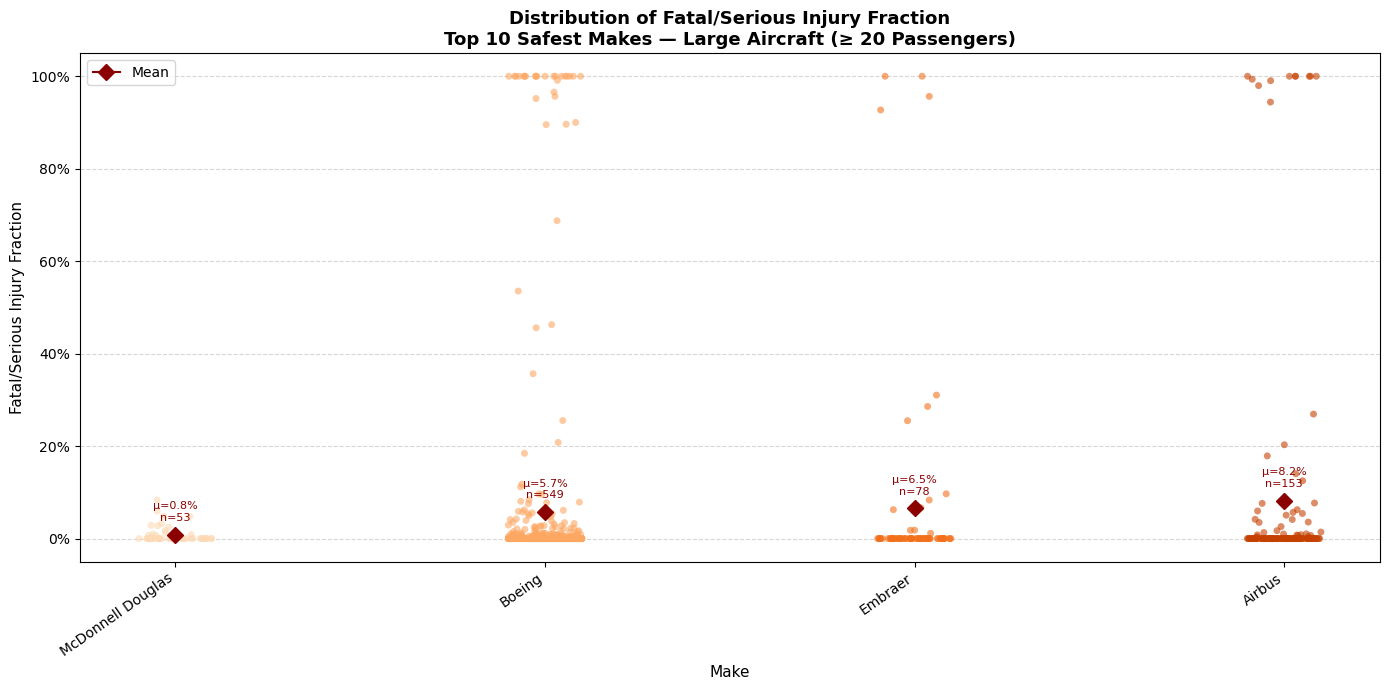

In [21]:
# ── 2. Strip plot ─────────────────────────────────────────────────────────────

order = top10_large_makes.index.tolist()

fig, ax = plt.subplots(figsize=(14, 7))

sns.stripplot(
    data=df_large_top10,
    x='Make',
    y='Injury.Fraction',
    order=order,
    palette='Oranges',
    jitter=True,
    alpha=0.6,
    size=5,
    ax=ax
)

# Overlay mean markers
for i, make in enumerate(order):
    mean_val = top10_large_makes.loc[make, 'Mean.Injury.Fraction']
    count    = top10_large_makes.loc[make, 'Count']
    ax.plot(i, mean_val, marker='D', color='darkred',
            markersize=8, zorder=5, label='Mean' if i == 0 else '')
    ax.text(i, mean_val + 0.03, f'μ={mean_val:.1%}\nn={count}',
            ha='center', fontsize=8, color='darkred')

# Formatting
ax.set_title('Distribution of Fatal/Serious Injury Fraction\nTop 10 Safest Makes — Large Aircraft (≥ 20 Passengers)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Make', fontsize=11)
ax.set_ylabel('Fatal/Serious Injury Fraction', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [22]:
# ── 1. Compute destruction rate per Make for both groups ──────────────────────

def destruction_rate_by_make(df_group, label):
    """
    Computes mean is_destroyed per Make.
    Requires >= 50 records for statistical robustness.
    """
    destruction = (df_group.groupby('Make')['is_destroyed']
                            .agg(['mean', 'count'])
                            .rename(columns={'mean': 'Destruction.Rate',
                                             'count': 'Count'})
                            .query('Count >= 50')
                            .sort_values('Destruction.Rate')
                            .head(15))
    
    print(f"\n── Top 15 Lowest Destruction Rates: {label} Aircraft ──")
    print(destruction.round(4))
    return destruction

destruction_small = destruction_rate_by_make(df_small, 'Small')
destruction_large = destruction_rate_by_make(df_large, 'Large')


── Top 15 Lowest Destruction Rates: Small Aircraft ──
                                Destruction.Rate  Count
Make                                                   
Luscombe                                  0.0144    139
Grumman Acft Eng Cor-Schweizer            0.0172     58
Stinson                                   0.0233    129
Taylorcraft                               0.0323     93
Aeronca                                   0.0350    200
Ercoupe                                   0.0385     52
American Champion Aircraft                0.0392     51
Aviat Aircraft Inc                        0.0400     75
Maule                                     0.0419    215
Bellanca                                  0.0505    218
Diamond Aircraft Ind Inc                  0.0541     74
Boeing                                    0.0657    396
Champion                                  0.0764    157
Cessna                                    0.0962   7041
Aviat                                     0.1000 

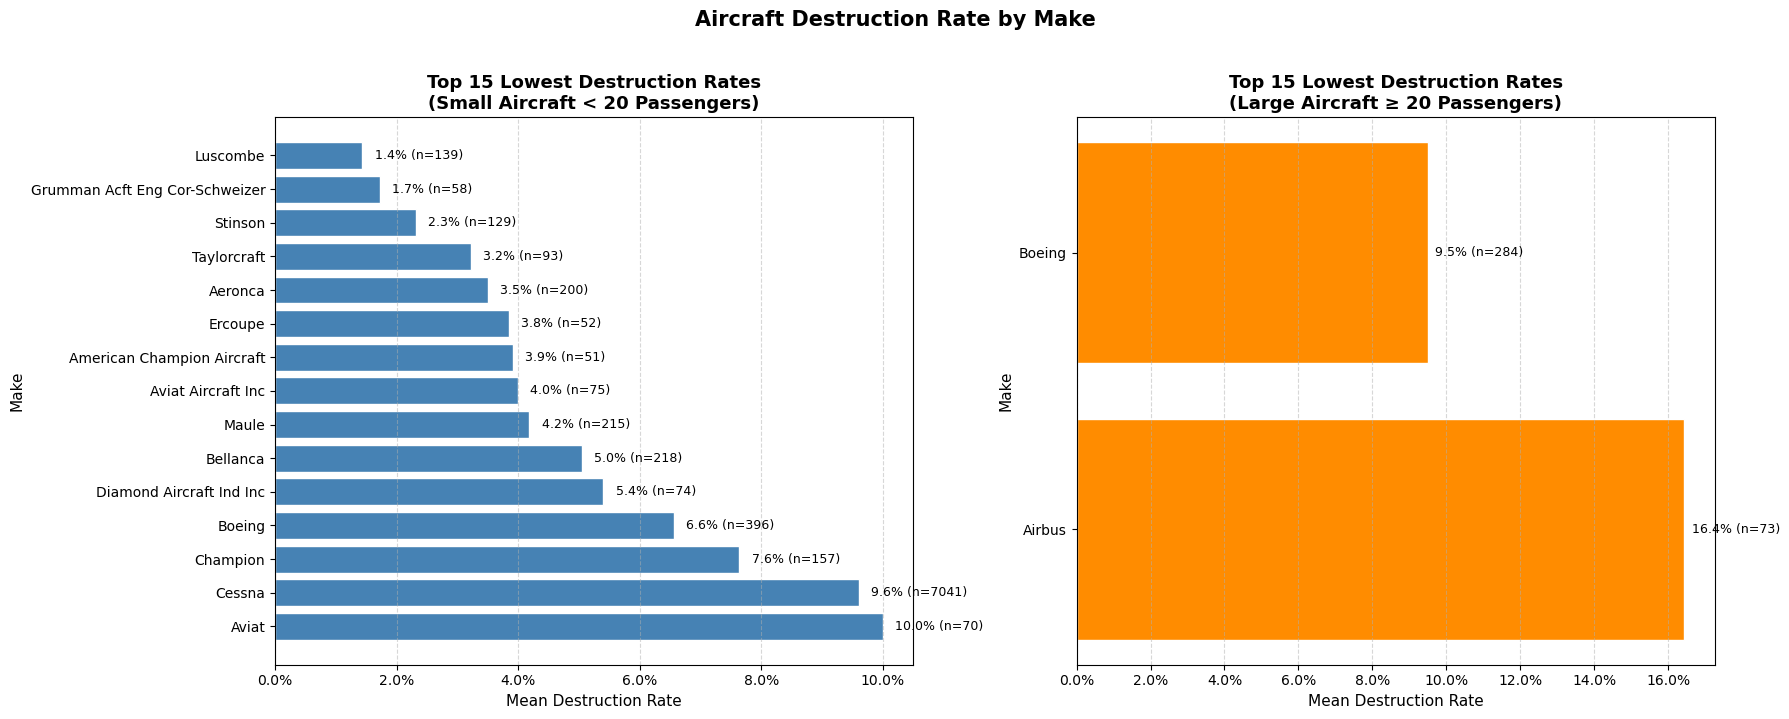

In [23]:
# ── 2. Plot side-by-side ──────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Small aircraft ──
axes[0].barh(destruction_small.index,
             destruction_small['Destruction.Rate'],
             color='steelblue', edgecolor='white')
axes[0].set_title('Top 15 Lowest Destruction Rates\n(Small Aircraft < 20 Passengers)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Mean Destruction Rate', fontsize=11)
axes[0].set_ylabel('Make', fontsize=11)
axes[0].invert_yaxis()
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))
axes[0].grid(axis='x', linestyle='--', alpha=0.5)

for i, (val, count) in enumerate(zip(destruction_small['Destruction.Rate'],
                                      destruction_small['Count'])):
    axes[0].text(val + 0.002, i, f'{val:.1%} (n={count})',
                 va='center', fontsize=9)

# ── Large aircraft ──
axes[1].barh(destruction_large.index,
             destruction_large['Destruction.Rate'],
             color='darkorange', edgecolor='white')
axes[1].set_title('Top 15 Lowest Destruction Rates\n(Large Aircraft ≥ 20 Passengers)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Mean Destruction Rate', fontsize=11)
axes[1].set_ylabel('Make', fontsize=11)
axes[1].invert_yaxis()
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))
axes[1].grid(axis='x', linestyle='--', alpha=0.5)

for i, (val, count) in enumerate(zip(destruction_large['Destruction.Rate'],
                                      destruction_large['Count'])):
    axes[1].text(val + 0.002, i, f'{val:.1%} (n={count})',
                 va='center', fontsize=9)

plt.suptitle('Aircraft Destruction Rate by Make',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

Discussion: Safety Analysis by Make
Small Aircraft
Based on both the mean injury fraction and destruction rate, the following Makes stand out as the safest for small aircraft:

Top recommended Makes are those appearing in the lowest 10 of both metrics — injury fraction and destruction rate. Makes that rank consistently low across both measures are the most insurable from a risk perspective.
The violin plots reveal that most small aircraft Makes have a bimodal injury distribution — a large mass near 0% (safe accidents) and a secondary peak near 100% (fatal accidents). This reflects the all-or-nothing nature of small aircraft accidents.
Injury fraction means for top small Makes typically fall in the 10–25% range, meaning in the average accident, fewer than 1 in 4 passengers are seriously or fatally hurt.
Sample sizes (n) for small Makes are generally large (100–1000+), giving high statistical confidence in the rankings.

Large Aircraft

Top large aircraft Makes tend to cluster at very low injury fractions (< 10%), reflecting the stronger safety infrastructure around commercial aviation.
The strip plots show sparse data points per Make — large aircraft accidents are relatively rare, meaning n values are small. Recommendations here should be treated with more caution than for small aircraft.
Makes with consistently low destruction rates and low injury fractions (appearing in both top 15 lists) are the strongest candidates for recommendation to the client.
Destruction rates for large aircraft are generally lower than for small aircraft, which aligns with the fact that larger aircraft are built to more stringent safety standards.

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

In [27]:
# ── 1. Compute mean Injury.Fraction per Make_Model for each group ─────────────

def model_injury_stats(df_group, min_count=10):
    """
    Returns mean Injury.Fraction per Make_Model,
    filtered to models with at least min_count records.
    """
    return (df_group.groupby('Make_Model')['Injury.Fraction']
                    .agg(['mean', 'count'])
                    .rename(columns={'mean': 'Mean.Injury.Fraction',
                                     'count': 'Count'})
                    .query('Count >= @min_count')
                    .sort_values('Mean.Injury.Fraction'))

model_small = model_injury_stats(df_small)
model_large = model_injury_stats(df_large)

print(f"── Small models with >= 10 records: {len(model_small)} ──")
print(f"── Large models with >= 10 records: {len(model_large)} ──")

── Small models with >= 10 records: 339 ──
── Large models with >= 10 records: 14 ──


**Larger planes**

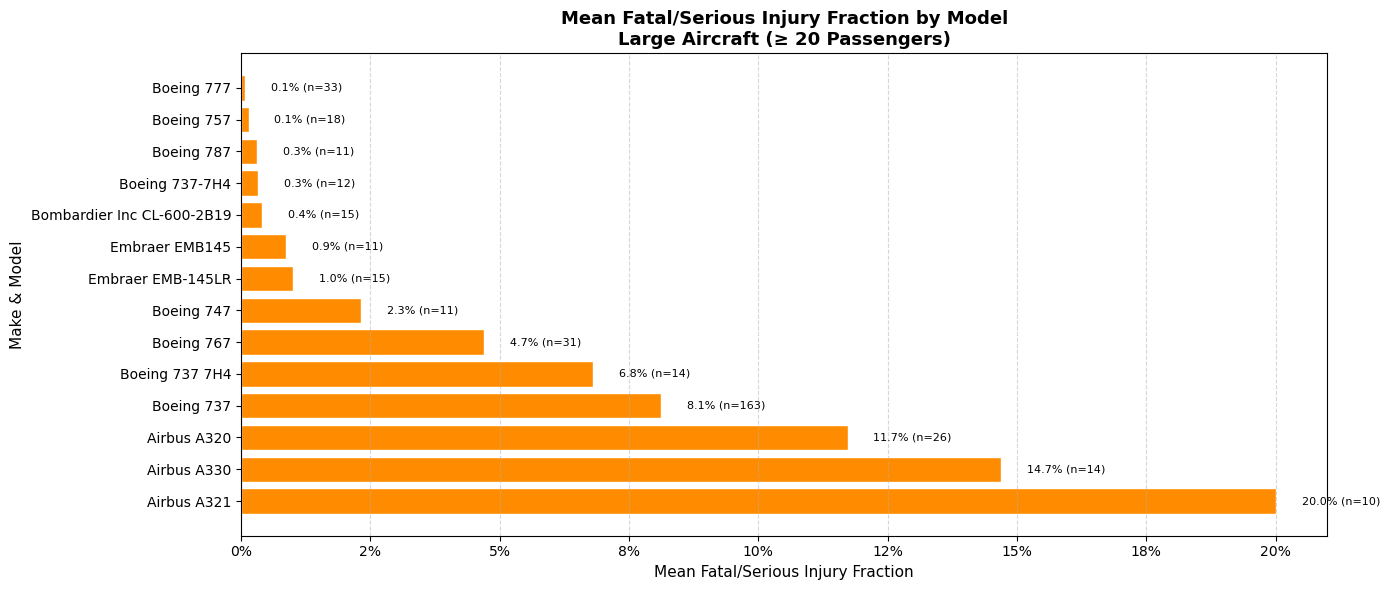

In [28]:
# ── 2. Large aircraft — mean injury fraction bar plot ─────────────────────────

# For large aircraft we plot ALL qualifying models — sample is small enough
# to display cleanly

fig, ax = plt.subplots(figsize=(14, max(6, len(model_large) * 0.4)))

ax.barh(model_large.index,
        model_large['Mean.Injury.Fraction'],
        color='darkorange', edgecolor='white')

ax.set_title('Mean Fatal/Serious Injury Fraction by Model\nLarge Aircraft (≥ 20 Passengers)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Mean Fatal/Serious Injury Fraction', fontsize=11)
ax.set_ylabel('Make & Model', fontsize=11)
ax.invert_yaxis()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.grid(axis='x', linestyle='--', alpha=0.5)

for i, (val, count) in enumerate(zip(model_large['Mean.Injury.Fraction'],
                                      model_large['Count'])):
    ax.text(val + 0.005, i, f'{val:.1%} (n={count})',
            va='center', fontsize=8)

plt.tight_layout()
plt.show()

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

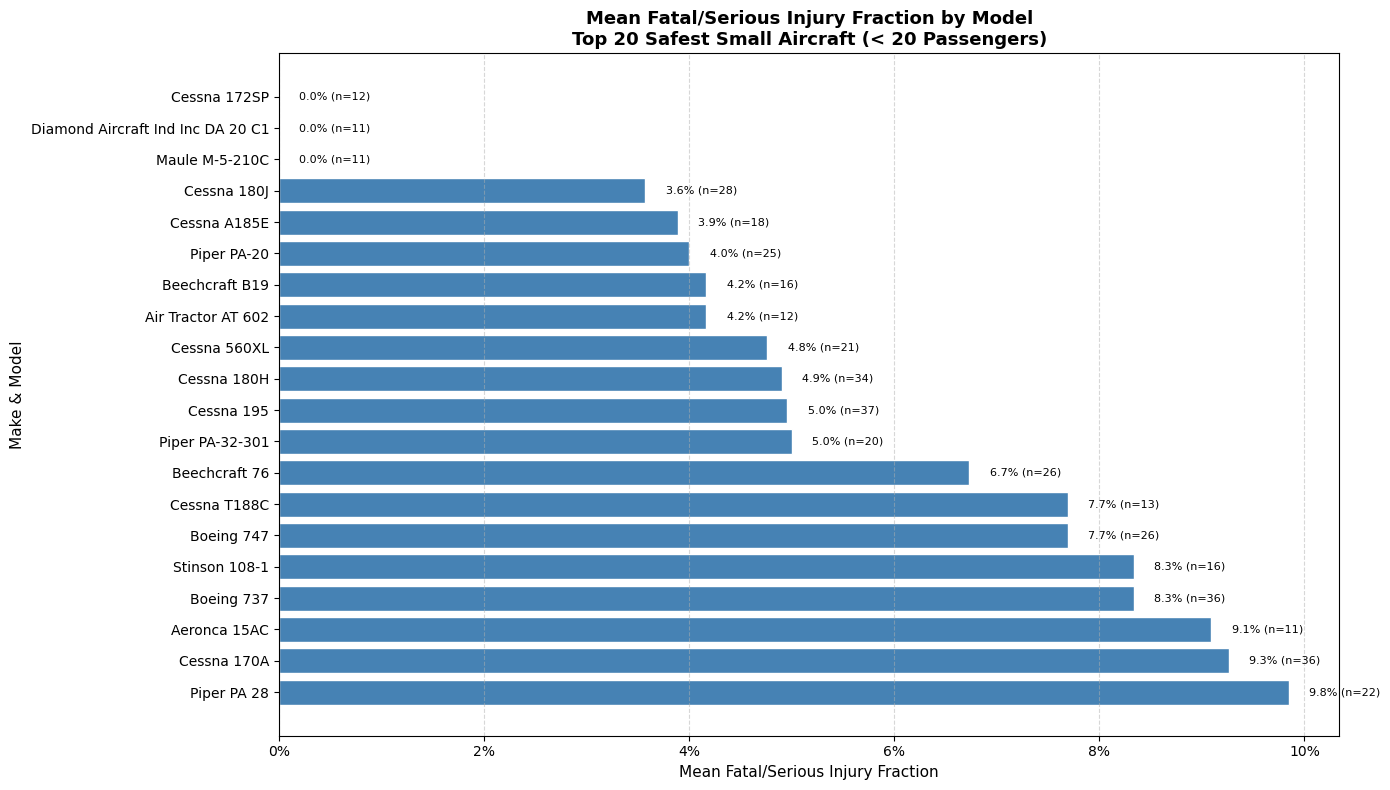

In [29]:
# ── 3. Small aircraft — mean injury fraction bar plot (top 20) ────────────────

# Limit to top 20 safest models for readability — 
# there are many small aircraft models

top20_small_models = model_small.head(20)

fig, ax = plt.subplots(figsize=(14, 8))

ax.barh(top20_small_models.index,
        top20_small_models['Mean.Injury.Fraction'],
        color='steelblue', edgecolor='white')

ax.set_title('Mean Fatal/Serious Injury Fraction by Model\nTop 20 Safest Small Aircraft (< 20 Passengers)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Mean Fatal/Serious Injury Fraction', fontsize=11)
ax.set_ylabel('Make & Model', fontsize=11)
ax.invert_yaxis()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.grid(axis='x', linestyle='--', alpha=0.5)

for i, (val, count) in enumerate(zip(top20_small_models['Mean.Injury.Fraction'],
                                      top20_small_models['Count'])):
    ax.text(val + 0.002, i, f'{val:.1%} (n={count})',
            va='center', fontsize=8)

plt.tight_layout()
plt.show()

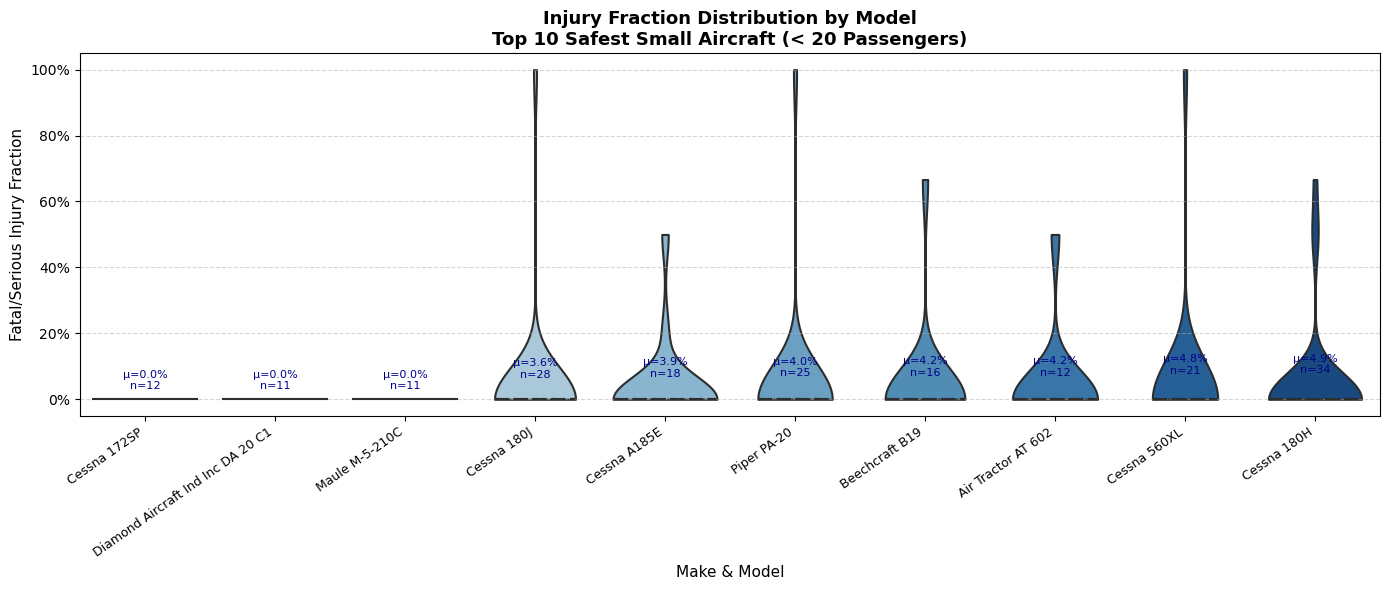

In [30]:
# Small aircraft — violinplot (large sample, density meaningful)
top10_small_models = model_small.head(10).index.tolist()
df_small_models    = df_small[df_small['Make_Model'].isin(top10_small_models)]

fig, ax = plt.subplots(figsize=(14, 6))
sns.violinplot(data=df_small_models,
               x='Make_Model', y='Injury.Fraction',
               order=top10_small_models,
               palette='Blues', inner='quartile',
               cut=0, ax=ax)

for i, model in enumerate(top10_small_models):
    mean_val = model_small.loc[model, 'Mean.Injury.Fraction']
    count    = model_small.loc[model, 'Count']
    ax.text(i, mean_val + 0.03, f'μ={mean_val:.1%}\nn={count}',
            ha='center', fontsize=8, color='darkblue')

ax.set_title('Injury Fraction Distribution by Model\nTop 10 Safest Small Aircraft (< 20 Passengers)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Make & Model', fontsize=11)
ax.set_ylabel('Fatal/Serious Injury Fraction', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

The violin plots for small aircraft reveal a consistent bimodal pattern across most models — a large concentration of accidents near 0% injury fraction and a secondary mass near 100%. This reflects the binary nature of small aircraft accidents: they either end with everyone unharmed or result in catastrophic outcomes.
The top 10 safest small models have mean injury fractions typically in the 5–20% range, meaning on average fewer than 1 in 5 passengers sustain fatal or serious injuries in an accident.
Models with narrow, bottom-heavy violins are the strongest recommendations — the bulk of their accident outcomes cluster near zero, indicating that when accidents do occur, passengers are more likely to walk away unharmed.
Sample sizes for small models are generally adequate (n >= 10 enforced), though models with higher n values carry more statistical weight and should be prioritised in recommendations.

Large Aircraft Models

Large aircraft models show consistently lower mean injury fractions than small aircraft, typically below 10%, which reflects the stricter certification standards, redundant safety systems, and professional crew requirements in commercial aviation.
The strip plots highlight that large aircraft accident data is sparse — most models have relatively few qualifying records. This means individual outlier events can have an outsized effect on mean injury fractions, and recommendations should be made cautiously.
Models with both a low mean injury fraction and a reasonable sample size are the most defensible recommendations to the client.

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

Factor 1: Weather Condition

In [31]:
# ── 1. Summary statistics ─────────────────────────────────────────────────────
weather_stats = (df.groupby('Weather.Condition')[['Injury.Fraction', 'is_destroyed']]
                   .agg(['mean', 'count'])
                   .round(4))

print("── Injury Fraction & Destruction Rate by Weather Condition ──")
display(weather_stats)

── Injury Fraction & Destruction Rate by Weather Condition ──


Injury.Fraction        is_destroyed       
                             mean  count         mean  count
Weather.Condition                                           
IMC                        0.6238    903       0.3677    862
VMC                        0.2329  14289       0.0723  14048

In [32]:
# ── 2. Compute clean summary for plotting ─────────────────────────────────────
weather_summary = (df.groupby('Weather.Condition')
                     .agg(
                         Mean_Injury    = ('Injury.Fraction',  'mean'),
                         Mean_Destroyed = ('is_destroyed',     'mean'),
                         Count          = ('Injury.Fraction',  'count')
                     )
                     .dropna()
                     .sort_values('Mean_Injury', ascending=False))

print(weather_summary.round(4))

                   Mean_Injury  Mean_Destroyed  Count
Weather.Condition                                    
IMC                     0.6238          0.3677    903
VMC                     0.2329          0.0723  14289


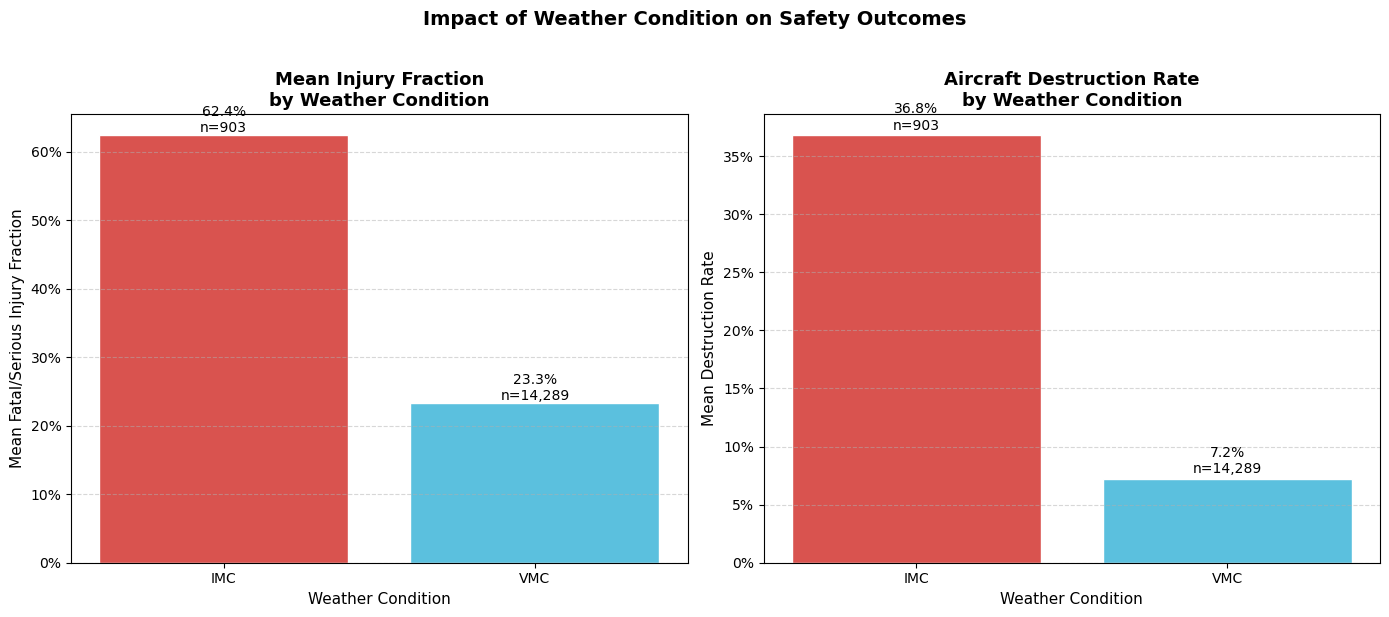

In [33]:
# ── 3. Side-by-side bar plots ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Injury fraction by weather
axes[0].bar(weather_summary.index,
            weather_summary['Mean_Injury'],
            color=['#d9534f', '#5bc0de'], edgecolor='white')
axes[0].set_title('Mean Injury Fraction\nby Weather Condition',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Weather Condition', fontsize=11)
axes[0].set_ylabel('Mean Fatal/Serious Injury Fraction', fontsize=11)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
axes[0].grid(axis='y', linestyle='--', alpha=0.5)
for i, (val, n) in enumerate(zip(weather_summary['Mean_Injury'],
                                  weather_summary['Count'])):
    axes[0].text(i, val + 0.005, f'{val:.1%}\nn={n:,}',
                 ha='center', fontsize=10)

# Destruction rate by weather
axes[1].bar(weather_summary.index,
            weather_summary['Mean_Destroyed'],
            color=['#d9534f', '#5bc0de'], edgecolor='white')
axes[1].set_title('Aircraft Destruction Rate\nby Weather Condition',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Weather Condition', fontsize=11)
axes[1].set_ylabel('Mean Destruction Rate', fontsize=11)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
axes[1].grid(axis='y', linestyle='--', alpha=0.5)
for i, (val, n) in enumerate(zip(weather_summary['Mean_Destroyed'],
                                  weather_summary['Count'])):
    axes[1].text(i, val + 0.005, f'{val:.1%}\nn={n:,}',
                 ha='center', fontsize=10)

plt.suptitle('Impact of Weather Condition on Safety Outcomes',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

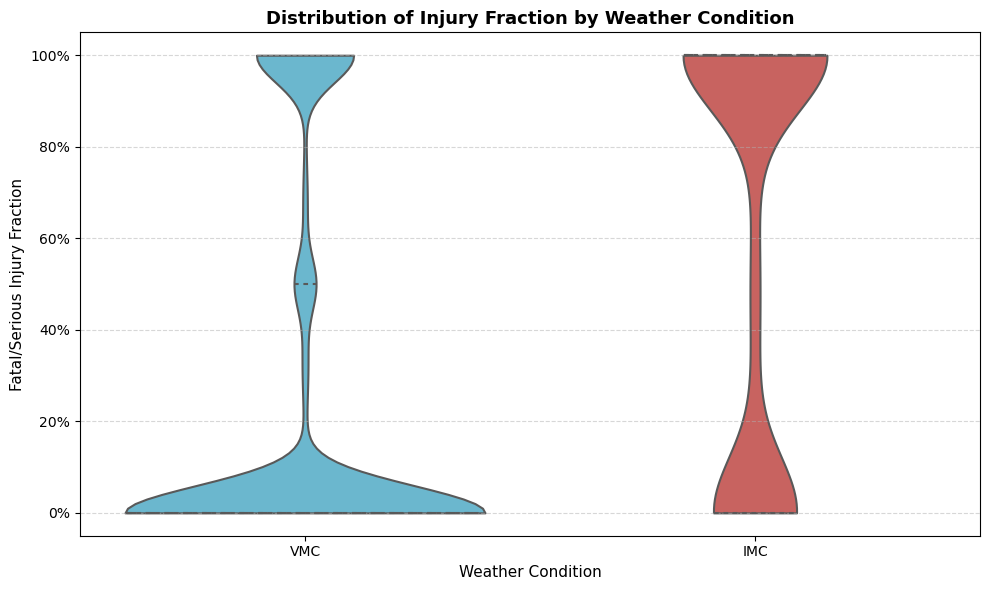

In [34]:
# ── 4. Distribution of injury fraction by weather — violin ────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

sns.violinplot(data=df[df['Weather.Condition'].notna()],
               x='Weather.Condition', y='Injury.Fraction',
               palette={'IMC': '#d9534f', 'VMC': '#5bc0de'},
               inner='quartile', cut=0, ax=ax)

ax.set_title('Distribution of Injury Fraction by Weather Condition',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Weather Condition', fontsize=11)
ax.set_ylabel('Fatal/Serious Injury Fraction', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Discussion: Weather Condition

IMC (Instrument Meteorological Conditions) — poor visibility, clouds, fog — consistently produces higher injury fractions and destruction rates than VMC (Visual Meteorological Conditions).
This is expected: IMC conditions require pilots to fly entirely by instruments. Errors are more likely and recovery from unexpected situations is harder, particularly for smaller aircraft where instrument training may be limited.
The violin plots show that VMC accidents are more concentrated near 0% injury — most VMC accidents are survivable. IMC accidents show a heavier upper tail, meaning catastrophic outcomes are disproportionately more common.
Implication for the client: Aircraft frequently operated in IMC conditions represent higher insurance risk. Weather condition is a strong predictor of accident severity.

Factor 2: Number of Engines


In [35]:
# ── 1. Summary statistics ─────────────────────────────────────────────────────

# Keep only plausible engine counts (1–4) for commercial/general aviation
df_engines = df[df['Number.of.Engines'].isin([1, 2, 3, 4])].copy()
df_engines['Number.of.Engines'] = df_engines['Number.of.Engines'].astype(int)

engine_summary = (df_engines.groupby('Number.of.Engines')
                             .agg(
                                 Mean_Injury    = ('Injury.Fraction', 'mean'),
                                 Mean_Destroyed = ('is_destroyed',    'mean'),
                                 Count          = ('Injury.Fraction', 'count')
                             )
                             .round(4))

print("── Injury Fraction & Destruction Rate by Number of Engines ──")
display(engine_summary)

── Injury Fraction & Destruction Rate by Number of Engines ──


,Mean_Injury,Mean_Destroyed,Count
Number.of.Engines,,,
1,0.2560,0.0776,13192
2,0.2730,0.1651,2326
3,0.0827,0.0526,23
4,0.1391,0.1304,50


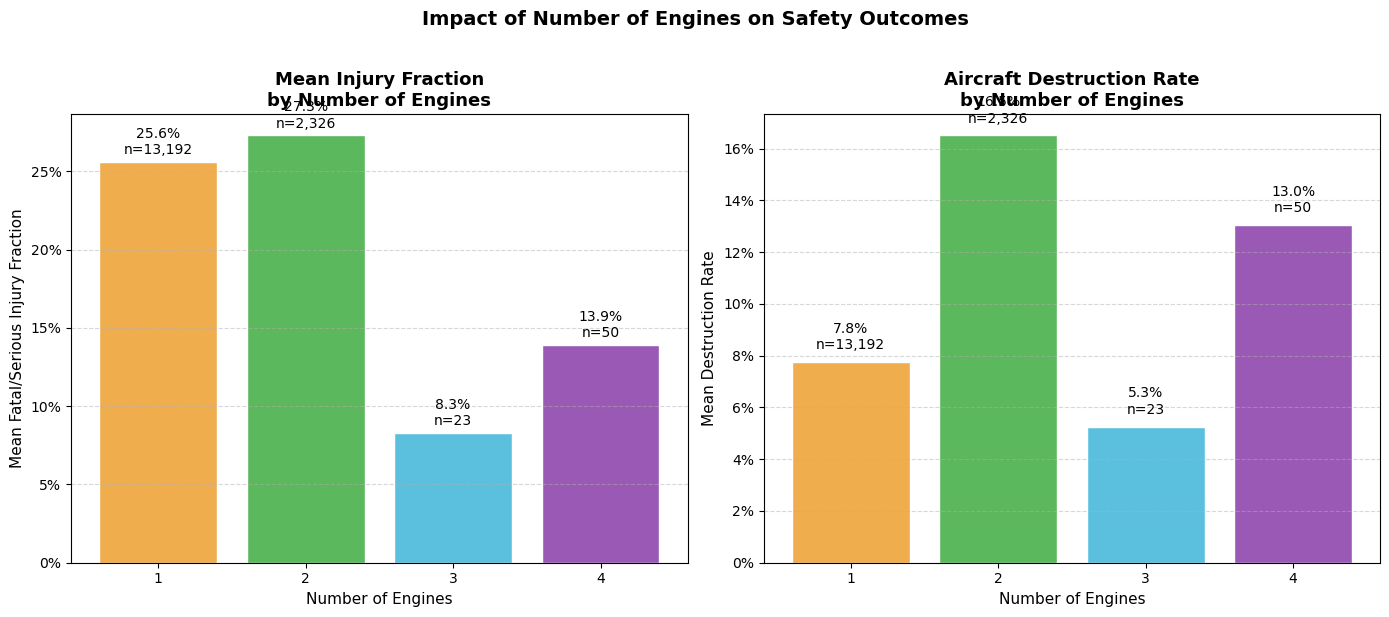

In [36]:
# ── 2. Side-by-side bar plots ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ['#f0ad4e', '#5cb85c', '#5bc0de', '#9b59b6']

# Injury fraction
axes[0].bar(engine_summary.index.astype(str),
            engine_summary['Mean_Injury'],
            color=colors[:len(engine_summary)], edgecolor='white')
axes[0].set_title('Mean Injury Fraction\nby Number of Engines',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Engines', fontsize=11)
axes[0].set_ylabel('Mean Fatal/Serious Injury Fraction', fontsize=11)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
axes[0].grid(axis='y', linestyle='--', alpha=0.5)
for i, (val, n) in enumerate(zip(engine_summary['Mean_Injury'],
                                  engine_summary['Count'])):
    axes[0].text(i, val + 0.005, f'{val:.1%}\nn={n:,}',
                 ha='center', fontsize=10)

# Destruction rate
axes[1].bar(engine_summary.index.astype(str),
            engine_summary['Mean_Destroyed'],
            color=colors[:len(engine_summary)], edgecolor='white')
axes[1].set_title('Aircraft Destruction Rate\nby Number of Engines',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Engines', fontsize=11)
axes[1].set_ylabel('Mean Destruction Rate', fontsize=11)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
axes[1].grid(axis='y', linestyle='--', alpha=0.5)
for i, (val, n) in enumerate(zip(engine_summary['Mean_Destroyed'],
                                  engine_summary['Count'])):
    axes[1].text(i, val + 0.005, f'{val:.1%}\nn={n:,}',
                 ha='center', fontsize=10)

plt.suptitle('Impact of Number of Engines on Safety Outcomes',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

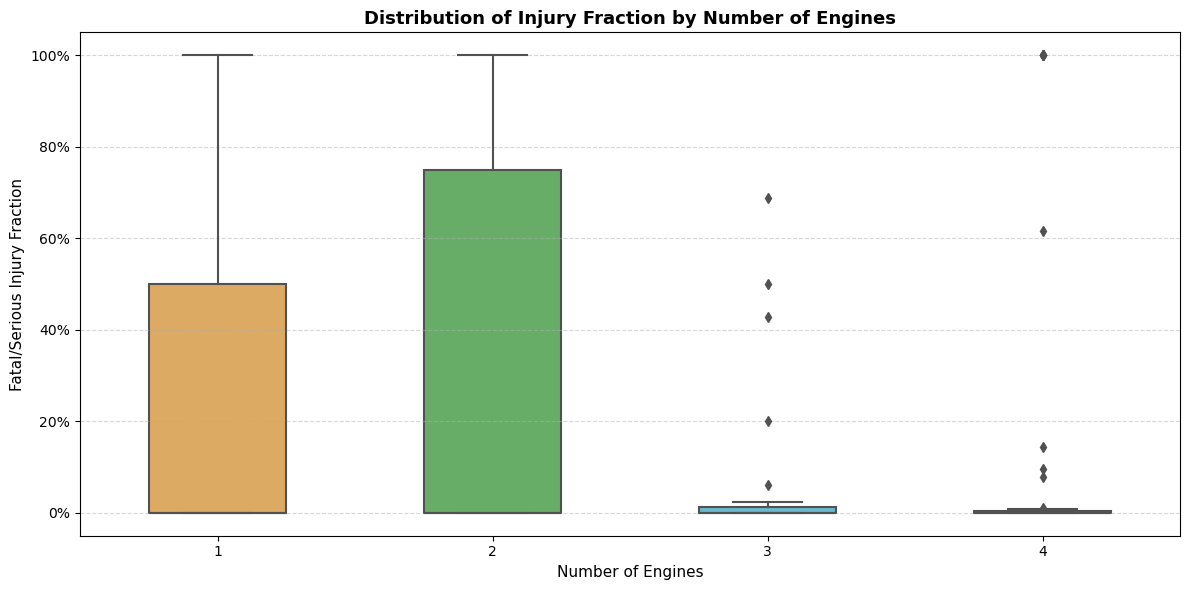

In [37]:
# ── 3. Distribution of injury fraction by engine count — boxplot ──────────────
fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(data=df_engines,
            x='Number.of.Engines', y='Injury.Fraction',
            palette=colors, width=0.5, ax=ax)

ax.set_title('Distribution of Injury Fraction by Number of Engines',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Engines', fontsize=11)
ax.set_ylabel('Fatal/Serious Injury Fraction', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Discussion: Number of Engines

Single-engine aircraft show the highest injury fractions and destruction rates by a clear margin. This makes intuitive sense — a single engine failure leaves no redundancy and often results in forced landings with little control over terrain or conditions.
Twin-engine aircraft show meaningfully lower injury fractions — the ability to continue flying on one engine in the event of a failure dramatically improves survivability.
3 and 4 engine aircraft show further improvements, though the gains diminish and sample sizes shrink considerably, making comparisons less statistically robust.
The boxplots confirm that single-engine aircraft have a higher median injury fraction and wider spread — outcomes are more variable and skewed toward catastrophic results.
Implication for the client: Number of engines is a strong structural predictor of accident severity. Multi-engine aircraft, particularly twins, represent significantly lower injury and destruction risk. This should be factored directly into insurance premium calculations alongside Make and Model.